# 第一课｜从膜电位到一个最小计算神经元

欢迎来到 FPGA FlyBrain 的第一课。

这门课从神经生理出发：膜电位会变化，突触输入会影响神经元，达到一定条件后会产生动作电位。我们会逐步把这些概念翻译成 **数学模型 → 程序 → 数字电路 → 最终运行在真实硬件上的神经网络**。

今天先不学硬件。我们只问一个问题：

> **如果目标是研究大规模神经网络的计算，最少需要保留神经元的哪些性质？**

这一课还会坚持一个原则：**每引入一个新机制，先让它单独出现在实验里，再把它和其他机制组合。**

## 1. 你现在看到的是什么：Jupyter Notebook

你正在阅读一个 **Jupyter Notebook**。它把教材和实验放在同一个页面里：

- **Markdown 单元格**：写解释、公式、问题和结论；
- **Code 单元格**：运行 Python 代码，马上观察结果。

所以 Notebook 不只是装代码的容器。它本身就是一份**可以运行的教材**。本课会反复使用“先预测 → 再运行 → 看图 → 解释”的方式建立直觉。

## 2. 我们最终要去哪里：什么是 FPGA？

**现场可编程门阵列（Field-Programmable Gate Array, FPGA）** 是一种可以在制造完成以后，根据设计重新配置内部数字电路的芯片。

普通电脑上的 **中央处理器（Central Processing Unit, CPU）** 通常按指令序列执行程序；FPGA 则可以把某些计算直接组织成并行数字电路。

这个项目最终会把神经元状态、突触事件和网络传播变成 FPGA 中的硬件结构。今天先把终点放在脑后，只理解神经元模型。

## 3. 从神经生理开始

先保留四个熟悉的事实：

1. 神经元膜两侧存在电位差，也就是**膜电位**；
2. 突触输入会改变膜电位；
3. 没有持续输入时，膜电位倾向回到一个稳定状态；
4. 当膜电位达到一定条件时，神经元可以产生动作电位。

真实神经元还包含离子通道、树突、不同递质、适应、突触动力学、细胞类型差异等大量细节。第一课不试图复制完整细胞，而是保留几种对计算最重要的行为。

## 4. 什么是模型？

一个 **模型（model）** 是针对当前问题做出的有目的简化。它保留我们暂时关心的关系，同时忽略其他细节。

地铁图不会画出每一栋建筑，但会保留“哪些站相连”。同样，我们的第一版神经元模型不会重建完整动作电位波形，而会保留：

- 一个随时间变化的膜电位状态；
- 输入对状态的影响；
- 状态随时间衰减；
- 达到阈值后产生一次 spike 事件。

## 5. 什么是 LIF？先把名字拆开

我们使用经典的 **漏电积分发放模型（Leaky Integrate-and-Fire, LIF）**。

三个词对应三个动作：

- **Leaky，漏电/衰减**：没有新输入时，偏离静息状态的膜电位会逐渐回落；
- **Integrate，积分/累积**：新的输入会加入当前膜电位状态；
- **Fire，发放**：膜电位达到阈值后，模型产生一次 spike 事件。

这里的 **spike** 只表示“这个时刻发生了一次发放事件”。我们暂时不模拟真实动作电位完整的上升、下降和离子通道动力学。

## 6. 先写出 leak，再谈 fire

真实的被动膜常用下面的形式描述：

$$\tau_m \frac{dV}{dt} = -(V - V_{rest}) + R_m I(t)$$

这里：

- $V$ 是膜电位；
- $V_{rest}$ 是静息膜电位；
- $\tau_m$ 是**膜时间常数（membrane time constant）**，决定偏离静息电位的影响能保留多久；
- $R_m I(t)$ 表示输入电流对膜电位的驱动。

为了先建立离散时间直觉，我们把它写成一个教学用更新规则：

$$V[t+1] = V_{rest} + \alpha \big(V[t] - V_{rest}\big) + u[t]$$

其中 $u[t]$ 是这一时间步输入带来的“等效膜电位增量”。第一课先把电阻、时间步长等比例因子吸收到 $u[t]$ 里，所以它不是完整生物物理单位下的电流方程。

$0 < \alpha < 1$ 时，旧状态只保留一部分。对于纯 leak，一个常用关系是 $\alpha \approx e^{-\Delta t / \tau_m}$：$\alpha$ 越接近 1，记忆越长；越小，衰减越快。

### 一个容易忽略的点

如果一开始就是 $V[0]=V_{rest}$，而且 $u[t]=0$，那么膜电位会一直停在静息电位。

这时模型**仍然有 leak**，但图上看不出来，因为没有任何偏离静息状态的量可以衰减。

所以第一个实验故意把初始膜电位抬高，再撤掉全部输入。这样我们能把 Leaky 单独看见。

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def run_leaky_integrator(inputs, *, alpha=0.9, v_rest=-70.0, v0=None):
    """Run only leak + integration. No threshold and no reset yet."""
    inputs = np.asarray(inputs, dtype=float)
    v = v_rest if v0 is None else float(v0)
    voltages = [v]

    for drive in inputs:
        v = v_rest + alpha * (v - v_rest) + drive
        voltages.append(v)

    return np.asarray(voltages)


def plot_input_and_voltage(inputs, voltages, *, title, threshold=None, spike_steps=None):
    inputs = np.asarray(inputs, dtype=float)
    fig, (ax_in, ax_v) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    ax_in.stem(np.arange(len(inputs)), inputs, basefmt=" ")
    ax_in.set_ylabel('input u[t]')
    ax_in.set_title(title)

    ax_v.plot(np.arange(len(voltages)), voltages, marker='o', markersize=3)
    ax_v.axhline(-70.0, linestyle='--', label='V_rest = -70 mV')
    if threshold is not None:
        ax_v.axhline(threshold, linestyle=':', label=f'threshold = {threshold} mV')
    if spike_steps is not None and threshold is not None and len(spike_steps):
        ax_v.scatter(np.asarray(spike_steps) + 1, [threshold] * len(spike_steps), marker='x', s=80, label='spike event')
    ax_v.set_xlabel('time step')
    ax_v.set_ylabel('membrane voltage (mV)')
    ax_v.legend()
    plt.tight_layout()
    plt.show()

## 7. Experiment 1 — 没有输入，只看 Leak

先把膜电位设成 `-55 mV`，高于静息电位 `-70 mV`，然后令所有输入为 0。

运行前先预测：膜电位会线性下降，还是一开始下降得快、后来越来越慢？

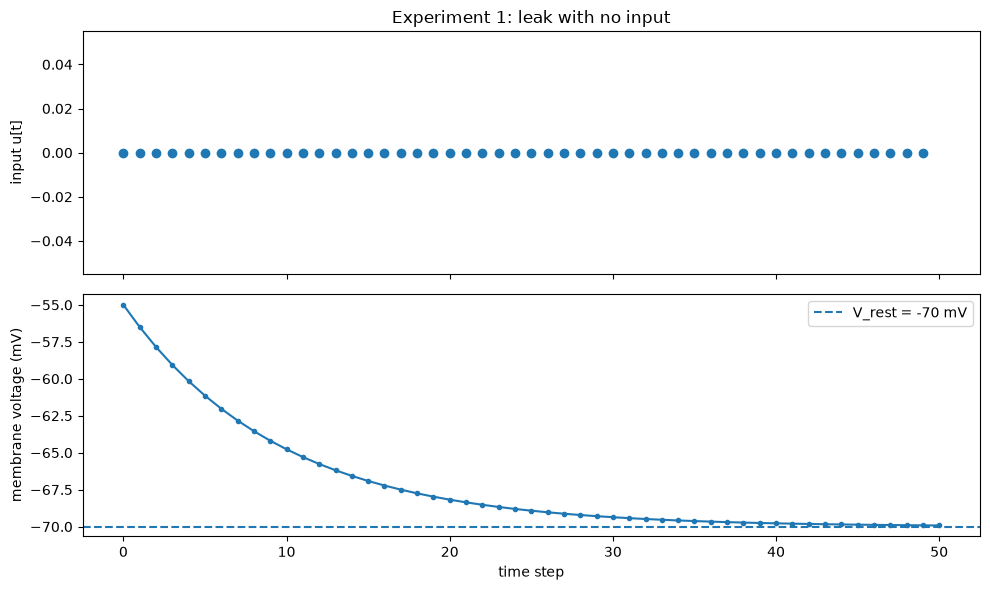

In [2]:
leak_inputs = np.zeros(50)
leak_voltage = run_leaky_integrator(
    leak_inputs,
    alpha=0.90,
    v_rest=-70.0,
    v0=-55.0,
)

plot_input_and_voltage(
    leak_inputs,
    leak_voltage,
    title='Experiment 1: leak with no input',
)

### 观察

上图的输入始终为 0；下图中，膜电位却不是保持在 `-55 mV`，而是逐渐回到 `-70 mV`。

这就是 **Leaky**。每一步只保留上一时刻“偏离静息电位”的一部分，所以曲线逐渐接近静息电位。

试着回答：

1. 为什么它最终接近 `-70 mV`，而不是无限下降？
2. 如果把 `alpha` 从 `0.90` 改成 `0.70`，回落会更快还是更慢？
3. 如果初始值改成 `-70 mV`，为什么图会变成水平线？

## 8. Experiment 2 — 等时间脉冲：同时看见 Integrate 和 Leak

现在每隔 8 个时间步给一次相同的正向输入。

每次输入都会把膜电位向上推；两个输入之间没有新驱动，膜电位又会向静息电位回落。下一次输入如果在前一次影响完全消失之前到达，就会在剩余状态上继续累积。

这张图应该同时出现两个动作：**输入时上升，间隔中回落。**

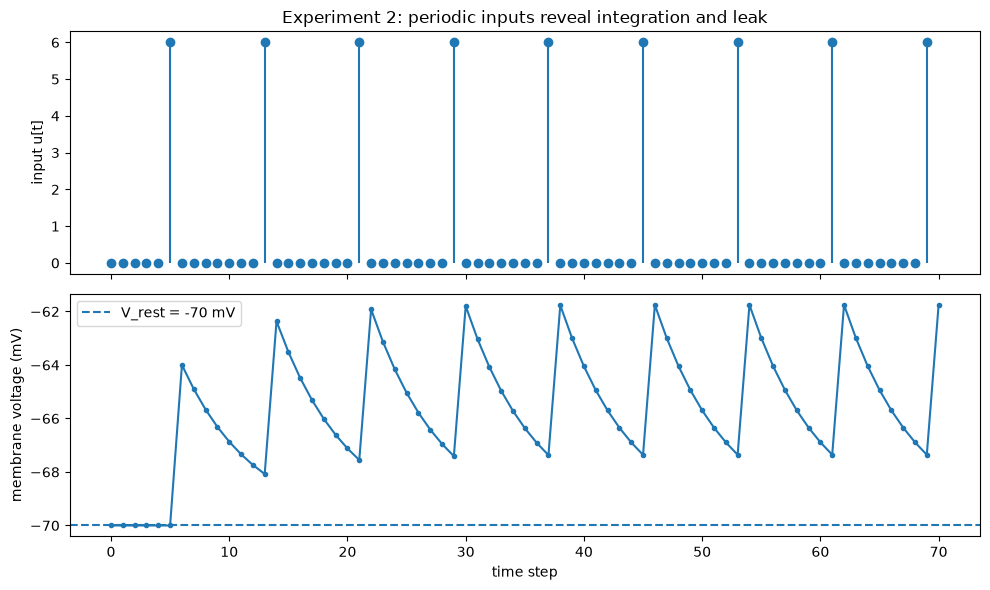

In [3]:
periodic_inputs = np.zeros(70)
periodic_inputs[5::8] = 6.0

periodic_voltage = run_leaky_integrator(
    periodic_inputs,
    alpha=0.85,
    v_rest=-70.0,
    v0=-70.0,
)

plot_input_and_voltage(
    periodic_inputs,
    periodic_voltage,
    title='Experiment 2: periodic inputs reveal integration and leak',
)

### 观察

不要只看峰值。重点看每两个脉冲之间的斜坡：

- 脉冲到达：膜电位向上跳；
- 没有输入：膜电位向 `V_rest` 回落；
- 下一脉冲到达：在尚未完全漏掉的状态上继续累积。

LIF 中的 “Integrate” 和 “Leaky” 并不是两个互相独立的阶段，而是在每一个时间步共同决定下一状态。

## 9. Experiment 3 — 输入间隔和膜时间常数之间的关系

保持脉冲幅度不变，只改变脉冲之间的时间间隔。

如果输入来得很快，前一个输入留下的状态还很多；如果输入来得很慢，前一个输入可能已经大部分漏掉。

这就是一个简单的“时间记忆”实验。

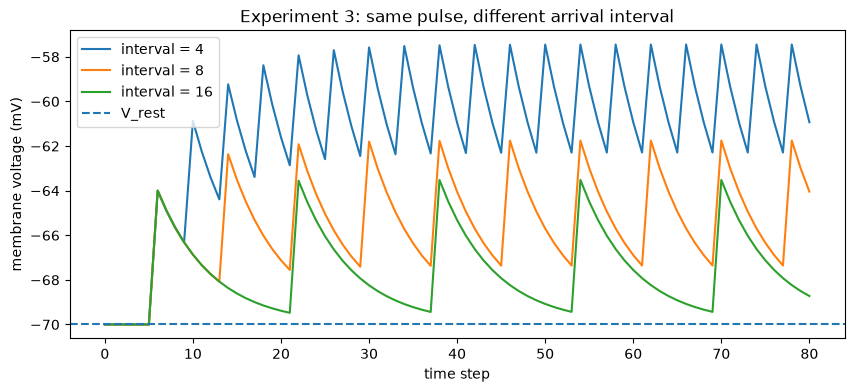

In [4]:
def make_periodic_inputs(length, interval, *, amplitude=6.0, start=5):
    x = np.zeros(length)
    x[start::interval] = amplitude
    return x


plt.figure(figsize=(10, 4))
for interval in (4, 8, 16):
    x = make_periodic_inputs(80, interval)
    v = run_leaky_integrator(x, alpha=0.85, v_rest=-70.0)
    plt.plot(np.arange(len(v)), v, label=f'interval = {interval}')

plt.axhline(-70.0, linestyle='--', label='V_rest')
plt.xlabel('time step')
plt.ylabel('membrane voltage (mV)')
plt.title('Experiment 3: same pulse, different arrival interval')
plt.legend()
plt.show()

### 观察

这里没有改变单个脉冲的大小，也没有改变 `alpha`。唯一改变的是**输入到达的时间关系**。

因此，如果几条曲线累积程度不同，原因不是“输入更强”，而是神经元保留了前一次输入的一部分状态。

这也是膜时间常数的重要直觉：它决定过去的输入还能影响未来多久。

## 10. Experiment 4 — 随机输入：累积和 Leak 交替出现

真实网络中的输入通常不会像节拍器一样整齐。下面用固定随机种子生成一个可重复的随机输入序列：事件到达时间随机，事件幅度也有一些变化。

固定随机种子是为了让你和别人运行 Notebook 时得到同一组输入，方便讨论和测试。

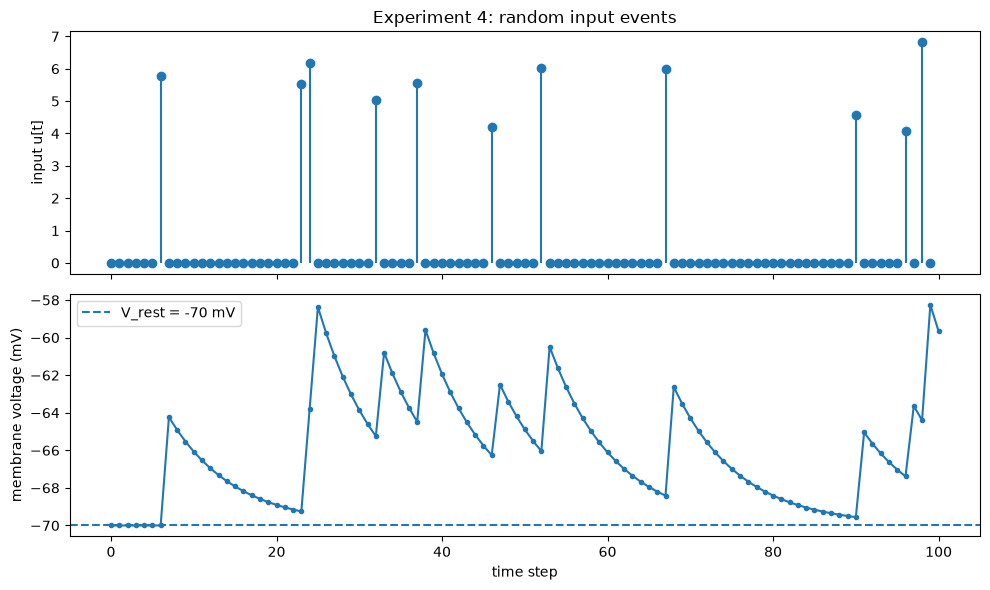

In [5]:
rng = np.random.default_rng(7)
random_events = rng.random(100) < 0.12
random_amplitudes = rng.uniform(4.0, 7.0, size=100)
random_inputs = random_events * random_amplitudes

random_voltage = run_leaky_integrator(
    random_inputs,
    alpha=0.88,
    v_rest=-70.0,
)

plot_input_and_voltage(
    random_inputs,
    random_voltage,
    title='Experiment 4: random input events',
)

### 观察

在输入密集的区域，膜电位更容易连续累积；输入稀疏时，膜电位会有更多时间向静息电位回落。

现在可以用一句完整的话描述 LIF 的时间行为：

> 当前膜电位不仅由“这一刻有没有输入”决定，还取决于过去输入留下多少状态，以及这些状态在等待过程中漏掉了多少。

## 11. Experiment 5 — 最后再加入 threshold 和 reset

到现在为止，我们只有 **Leaky Integrator**：会漏、会累积，但不会发放。

现在才加入 LIF 名字中的最后一个词 **Fire**。规则是：

1. 先按同一个 leak + integration 公式计算 `candidate_v`；
2. 如果 `candidate_v >= threshold`，记录一次 spike；
3. spike 后把真正保存到下一步的状态设为 `reset`。

这里必须区分两个值：

- `candidate_v`：阈值判断之前算出来的 next-state 候选值；
- `stored_v`：经过 threshold/reset 规则后真正保存的状态。

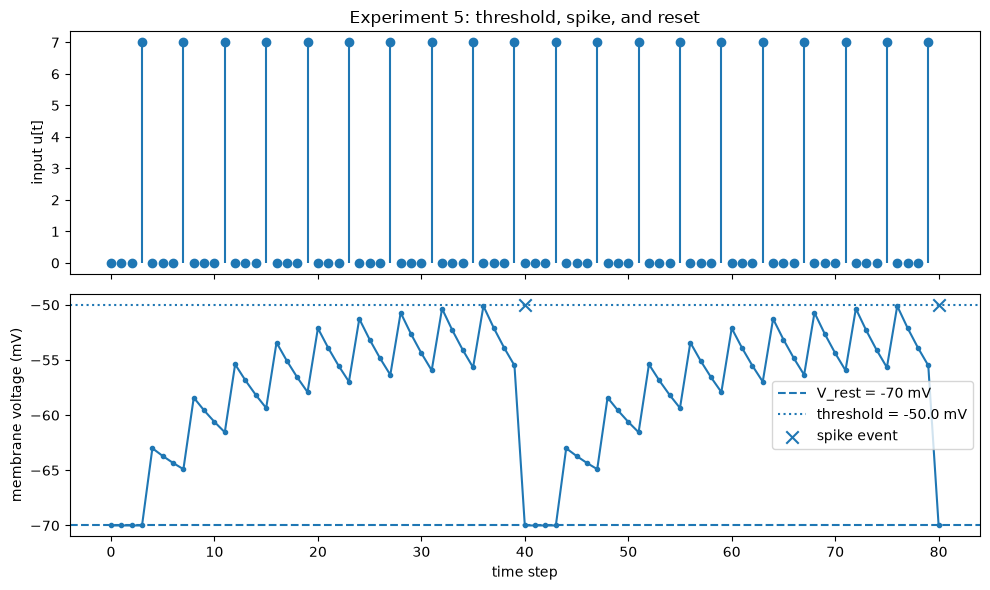

spike steps: [39 79]


In [6]:
def run_lif(inputs, *, alpha=0.9, v_rest=-70.0, v0=None, threshold=-50.0, reset=-70.0):
    inputs = np.asarray(inputs, dtype=float)
    v = v_rest if v0 is None else float(v0)
    stored_voltage = [v]
    candidate_voltage = []
    spike_steps = []

    for t, drive in enumerate(inputs):
        candidate_v = v_rest + alpha * (v - v_rest) + drive
        candidate_voltage.append(candidate_v)

        if candidate_v >= threshold:
            spike_steps.append(t)
            v = reset
        else:
            v = candidate_v

        stored_voltage.append(v)

    return {
        'inputs': inputs,
        'candidate_voltage': np.asarray(candidate_voltage),
        'stored_voltage': np.asarray(stored_voltage),
        'spike_steps': np.asarray(spike_steps, dtype=int),
    }


fire_inputs = np.zeros(80)
fire_inputs[3::4] = 7.0
trace = run_lif(fire_inputs, alpha=0.90, threshold=-50.0, reset=-70.0)

plot_input_and_voltage(
    trace['inputs'],
    trace['stored_voltage'],
    title='Experiment 5: threshold, spike, and reset',
    threshold=-50.0,
    spike_steps=trace['spike_steps'],
)

print('spike steps:', trace['spike_steps'])

## 12. 在第一个 spike 附近逐步读状态

图适合建立直觉，但数字能帮助我们检查更新顺序。下面只打印第一个 spike 附近几个时间步。

In [7]:
first_spike = int(trace['spike_steps'][0])
for t in range(first_spike - 2, first_spike + 2):
    did_spike = t in set(trace['spike_steps'].tolist())
    print({
        't': t,
        'input': trace['inputs'][t],
        'candidate_v': trace['candidate_voltage'][t],
        'stored_v': trace['stored_voltage'][t + 1],
        'spike': did_spike,
    })

{'t': 37, 'input': np.float64(0.0), 'candidate_v': np.float64(-53.88408265606225), 'stored_v': np.float64(-53.88408265606225), 'spike': False}
{'t': 38, 'input': np.float64(0.0), 'candidate_v': np.float64(-55.495674390456024), 'stored_v': np.float64(-55.495674390456024), 'spike': False}
{'t': 39, 'input': np.float64(7.0), 'candidate_v': np.float64(-49.94610695141042), 'stored_v': np.float64(-70.0), 'spike': True}
{'t': 40, 'input': np.float64(0.0), 'candidate_v': np.float64(-70.0), 'stored_v': np.float64(-70.0), 'spike': False}


这里有一个以后会直接映射到数字硬件的概念：**计算出来的 next state 和最终写入状态寄存器的 state 不一定相同。**

在 spike 时间步，`candidate_v` 达到阈值，但 `stored_v` 已经按照 reset 规则回到 `-70 mV`。后续课程会把这个更新顺序写成可测试的明确规范。

## 13. Try It — 每次只改一个因素

先写预测，再运行。可以任选一个：

- Experiment 1：把 `alpha=0.90` 改成 `0.70`，预测衰减曲线；
- Experiment 2：保持幅度不变，把输入间隔从 8 改成 4；
- Experiment 3：保持输入间隔不变，把 `alpha` 从 `0.85` 改成 `0.95`；
- Experiment 4：把随机事件概率从 `0.12` 改成 `0.25`；
- Experiment 5：把 threshold 从 `-50 mV` 改成 `-45 mV`。

每次只改一个因素，才能知道行为变化是由什么造成的。

## 14. AI Task

你可以让 AI 帮你：

- 生成更多输入模式，例如成簇到达的 burst 输入；
- 比较多个 `alpha` 或输入间隔；
- 把实验改成自动测试；
- 检查代码实现是否与公式一致。

给 AI 一个约束：

> 不要悄悄改变当前的更新顺序、threshold 规则或 reset 规则。如果认为规则应该改变，要明确说明这是一个规格修改，而不是普通代码重构。

AI 可以帮助写实现，但模型含义必须由我们明确决定。

## 15. Human Check

不用 AI，你应该能解释：

- 为什么 `V = V_rest` 且没有输入时，看不到明显的 leak 曲线；
- 为什么从高于 `V_rest` 的初始膜电位开始时，会看到回落；
- 周期脉冲之间为什么会下降，而多次脉冲为什么仍能累积；
- 输入间隔与膜时间常数为什么共同决定时间累积；
- 随机输入中哪些区域主要表现为 integration，哪些区域主要表现为 leak；
- `candidate_v` 与 `stored_v` 为什么可能不同；
- Leaky / Integrate / Fire 分别对应什么行为。

## 16. Engineering Handoff

这个 Notebook 仍然是教学原型。模型语义确认后，正式参考实现应放在：

`python/reference/lif_float.py`

之后 Notebook 应尽量导入正式模块，而不是长期维护一个行为略有不同的第二份实现。

特别是下面这些语义必须在进入 RTL 前冻结：更新顺序、threshold 比较方式、reset 规则、数值表示和时间步定义。

## 17. Project Trace

- Lesson ID: `LSN-001`
- Engineering slice: `RMD-001`
- Product requirement/design: `FR1 / DP1`
- Initial tests: `T-001 ~ T-004`

这些 ID 用来让课程、需求、代码和测试可以互相追踪。

## 18. Exit Ticket

继续下一课前，你应该能够：

1. 用自己的话解释科学模型为什么是有目的的简化；
2. 展开并解释 **Leaky Integrate-and-Fire (LIF)**；
3. 从零输入实验中指出 leak 在哪里；
4. 从周期输入实验中同时指出 integration 和 leak；
5. 解释为什么更短的输入间隔更容易保留并累积过去输入；
6. 解释随机输入下膜电位为何会时升时降；
7. 手工推演几个时间步，并说明 threshold/reset 何时发生。

如果这些已经比较自然，下一课会问：

> 当 `-70 mV`、`alpha` 和输入增量进入真正的数字硬件时，这些数到底怎样被表示和保存？